In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
# Silence some expected warnings
filterwarnings("ignore")
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn import metrics

In [5]:
def ROC(tr_y,tr_proba,te_y,te_proba,model_name,random_seed): # mcc,accuracy,auc,se,sp,tp, fn, fp, tn
    
    plt.rcParams['font.family'] = 'Times New Roman'
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Function to calculate the best threshold using Youden's J statistic
    def find_best_threshold(fpr, tpr, thresholds):
        J = tpr - fpr  # Youden's J statistic
        best_idx = np.argmax(J)  # Index of the maximum J value
        best_threshold = thresholds[best_idx]
        return best_threshold, fpr[best_idx], tpr[best_idx], J[best_idx]

    # Plot ROC curve for the training set
    fpr_train, tpr_train, thresholds_train = metrics.roc_curve(tr_y, tr_proba)
    auc_train = roc_auc_score(tr_y, tr_proba)
    # ax.plot(fpr_train, tpr_train, label=f"Train (AUROC = {auc_train:.3f})")
    ax.plot(fpr_train, tpr_train, label=f"Train (AUROC = {auc_train:.3f})", color='blue', linestyle='-', linewidth=2)

    
    # Find the best threshold for the training set
    best_threshold_train, best_fpr_train, best_tpr_train, J_train = find_best_threshold(fpr_train, tpr_train, thresholds_train)
    ax.scatter(best_fpr_train, best_tpr_train, marker="o", color="blue", s=100, label=f"Best Threshold (J = {J_train:.3f})")

    # Plot ROC curve for the test set
    fpr_test, tpr_test, thresholds_test = metrics.roc_curve(te_y, te_proba)
    auc_test = roc_auc_score(te_y, te_proba)
    # ax.plot(fpr_test, tpr_test, label=f"Test (AUROC = {auc_test:.3f})")
    ax.plot(fpr_test, tpr_test, label=f"Test (AUROC = {auc_test:.3f})",color='red', linestyle='-', linewidth=2)
    
    # Find the best threshold for the test set
    best_threshold_test, best_fpr_test, best_tpr_test, J_test = find_best_threshold(fpr_test, tpr_test, thresholds_test)
    ax.scatter(best_fpr_test, best_tpr_test, marker="o", color="red", s=100, label=f"Best Threshold (J = {J_test:.3f})")

    # Plot the diagonal line (random classifier)
    ax.plot([0, 1], [0, 1], "r--")  # Removed the label parameter

    # Add legend, title, and labels
    ax.legend(loc="lower right", fontsize=16)
    ax.set_title("ROC Curves: Seed 8, Rank 3", fontsize=28, fontweight='bold')
    ax.set_xlabel("False Positive Rate", fontsize=24,fontweight='bold')
    ax.set_ylabel("True Positive Rate", fontsize=24, fontweight='bold')

    # Only modification: tick labels thicker and slightly larger
    ax.tick_params(axis="both", labelsize=20, width=1.5)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')  # 字体加粗
    # Save the figure
    #fig.savefig(r'E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\roc_{model}_seed_{random_seed}.png'.format(model=model_name,random_seed=random_seed), dpi=900, bbox_inches="tight", transparent=False)
    plt.savefig("ROC Curves Seed 8 Rank 3.pdf", format='pdf', bbox_inches='tight')
    #return best_threshold_train, J_train, best_threshold_test, J_test

In [6]:
#### load predict_values files ####

# transformer
transformer_tr_8 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\result\8\Hyperparameters Rank 3\values_all_train_set_8.csv")
transformer_te_8 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\result\8\Hyperparameters Rank 3\values_all_test_set_8.csv")

transformer_tr_16 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_train_set_16.csv")
transformer_te_16 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_test_set_16.csv")

transformer_tr_24 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_train_set_24.csv")
transformer_te_24 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_test_set_24.csv")

transformer_tr_32 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_train_set_32.csv")
transformer_te_32 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_test_set_32.csv")

transformer_tr_48 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_train_set_48.csv")
transformer_te_48 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_test_set_48.csv")

transformer_tr_64 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_train_set_64.csv")
transformer_te_64 = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\03-Machine Learning\values_all_test_set_64.csv")

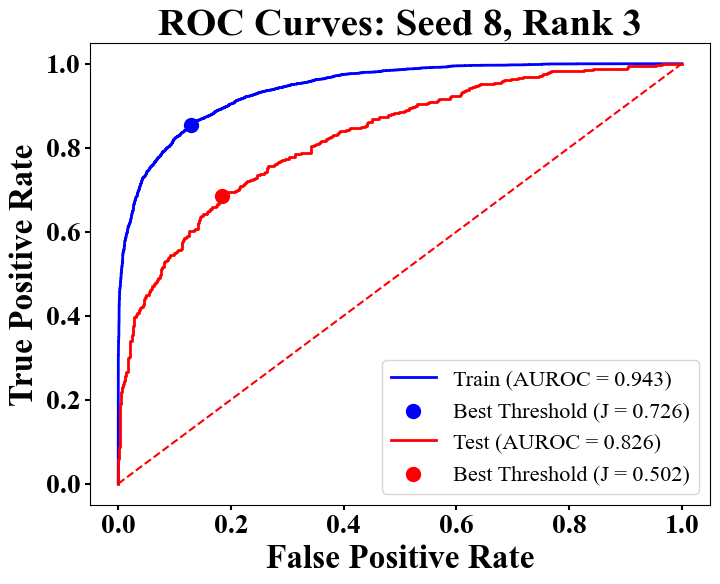

In [7]:
# transformer_8
ROC(transformer_tr_8['y'].to_list(),transformer_tr_8['probs'].to_list(),transformer_te_8['y'].to_list(),transformer_te_8['probs'].to_list(),'Transformer',8)